In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

In [2]:
dengue = pd.read_csv('DATASETS\\dengue.csv')

In [3]:
dengue 

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [4]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [5]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

In [6]:
dengue['Month'] = dengue['Month'].astype('category')
dengue['Region'] = dengue['Region'].astype('category')

In [7]:
dengue.dtypes

Month            category
Year                int64
Region           category
Dengue_Cases        int64
Dengue_Deaths       int64
dtype: object

# Line Plot

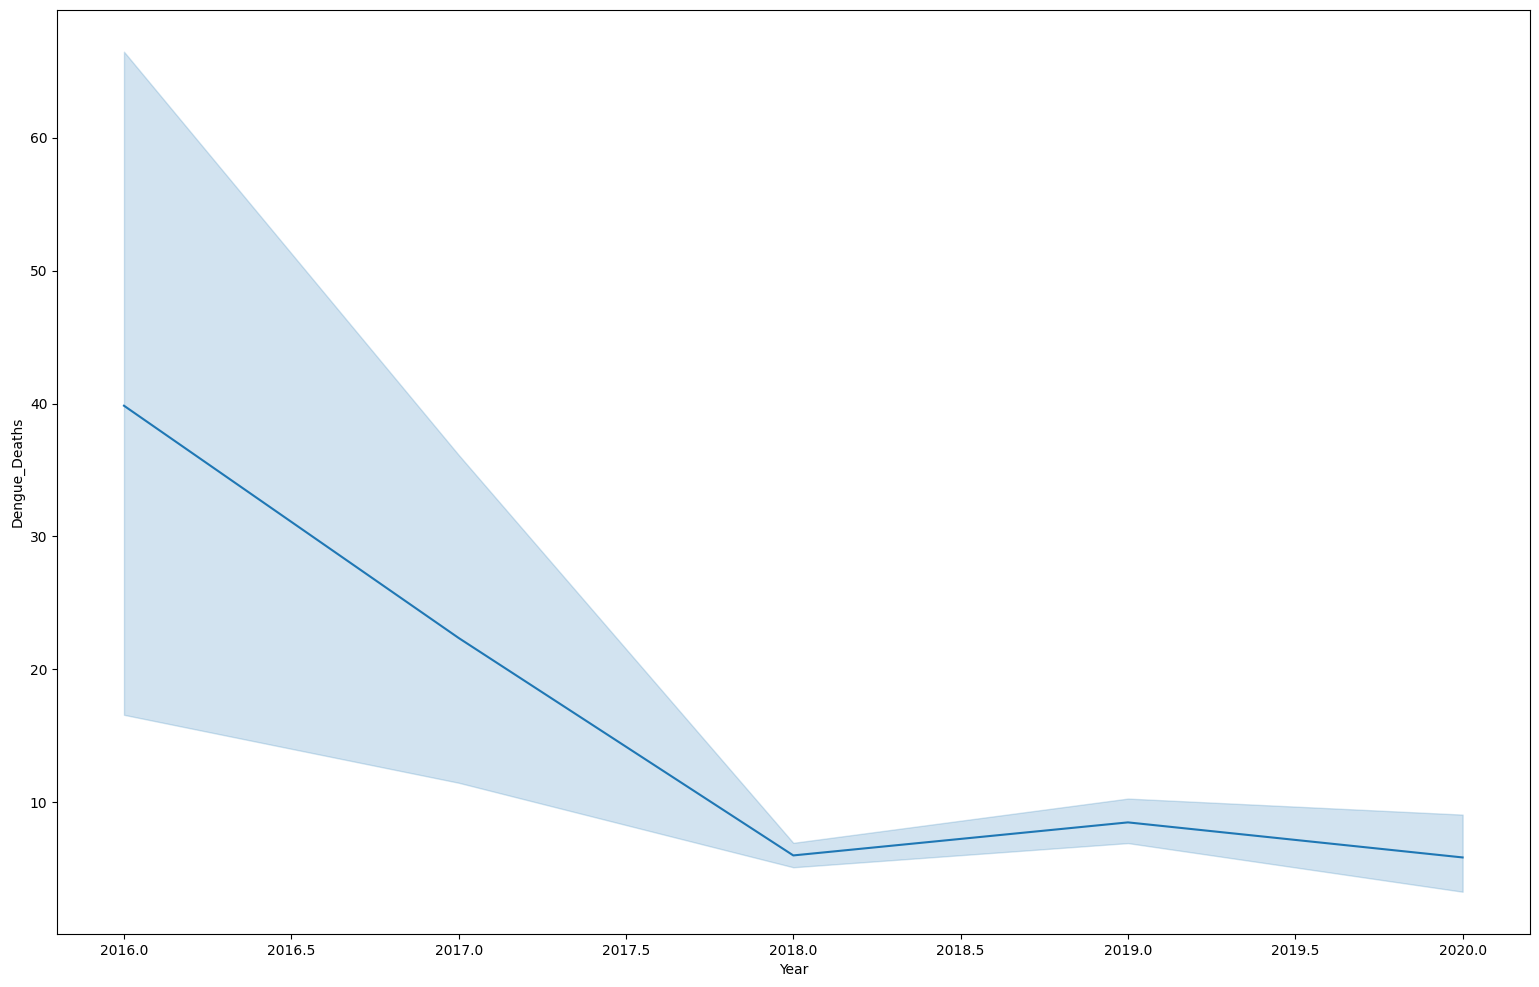

In [8]:
sns.lineplot(data=dengue, y="Dengue_Deaths", x="Year")
plt.gcf().set_size_inches(19,12)
plt.show()

# Box Plot

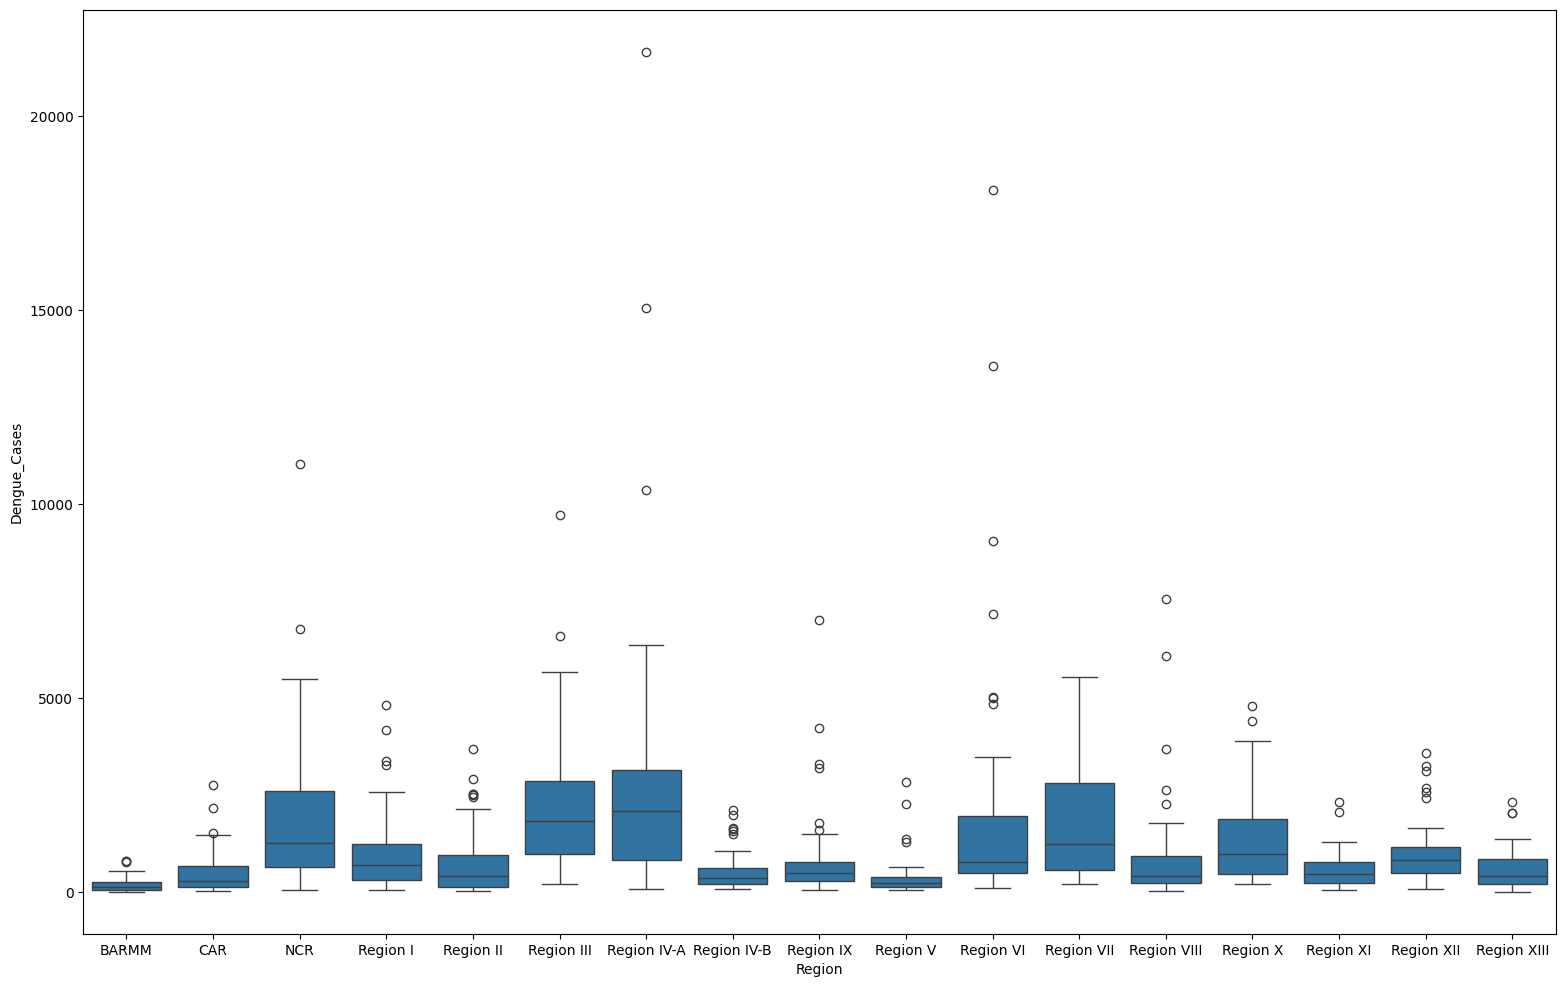

In [9]:
sns.boxplot(data=dengue, x="Region", y="Dengue_Cases")
plt.gcf().set_size_inches(19,12)
plt.show()

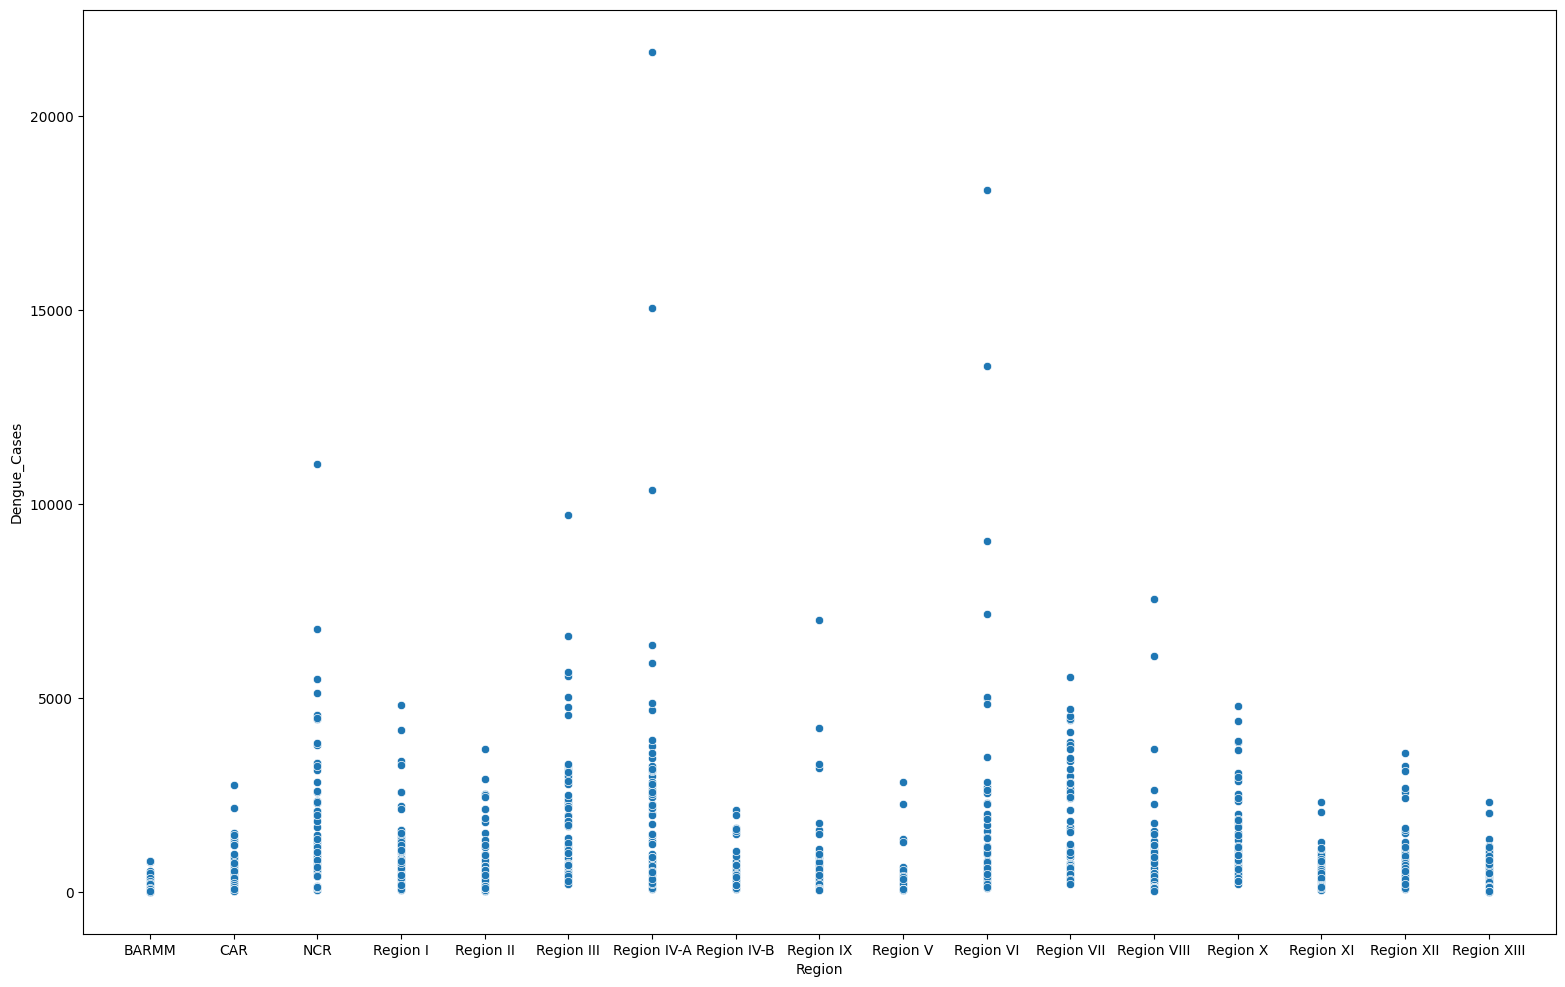

In [10]:
sns.scatterplot(data=dengue, x="Region", y="Dengue_Cases")
plt.gcf().set_size_inches(19,12)
plt.show()

In [11]:
dengue.dtypes

Month            category
Year                int64
Region           category
Dengue_Cases        int64
Dengue_Deaths       int64
dtype: object

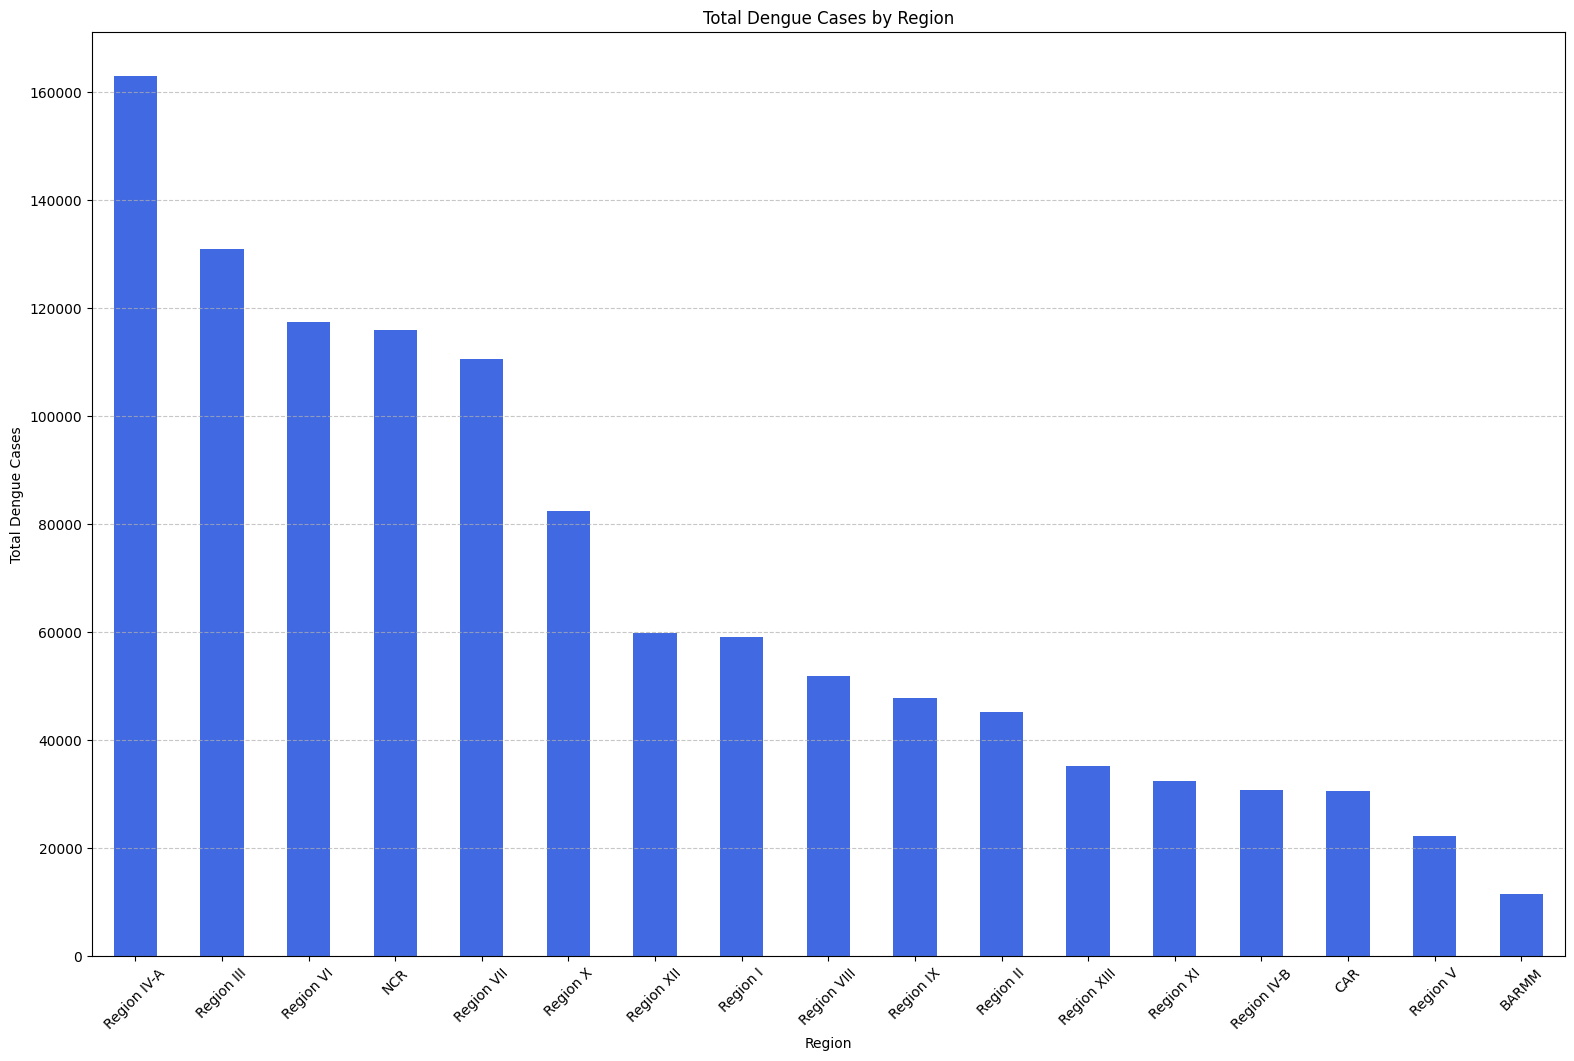

In [12]:
region_cases = dengue.groupby("Region")["Dengue_Cases"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
region_cases.plot(kind='bar', color='royalblue')
plt.gcf().set_size_inches(19,12)
plt.xlabel("Region")
plt.ylabel("Total Dengue Cases")
plt.title("Total Dengue Cases by Region")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# INSIGTH 1
These regions may have higher population densities, poor sanitation, or ideal mosquito breeding conditions. If one region is significantly higher than the others, it could indicate an outbreak hotspot that needs urgent attention



# INSIGTH 2

Regions with low dengue cases may have better mosquito control measures or lower population densities. These regions could serve as a benchmark to study what’s working in dengue prevention.



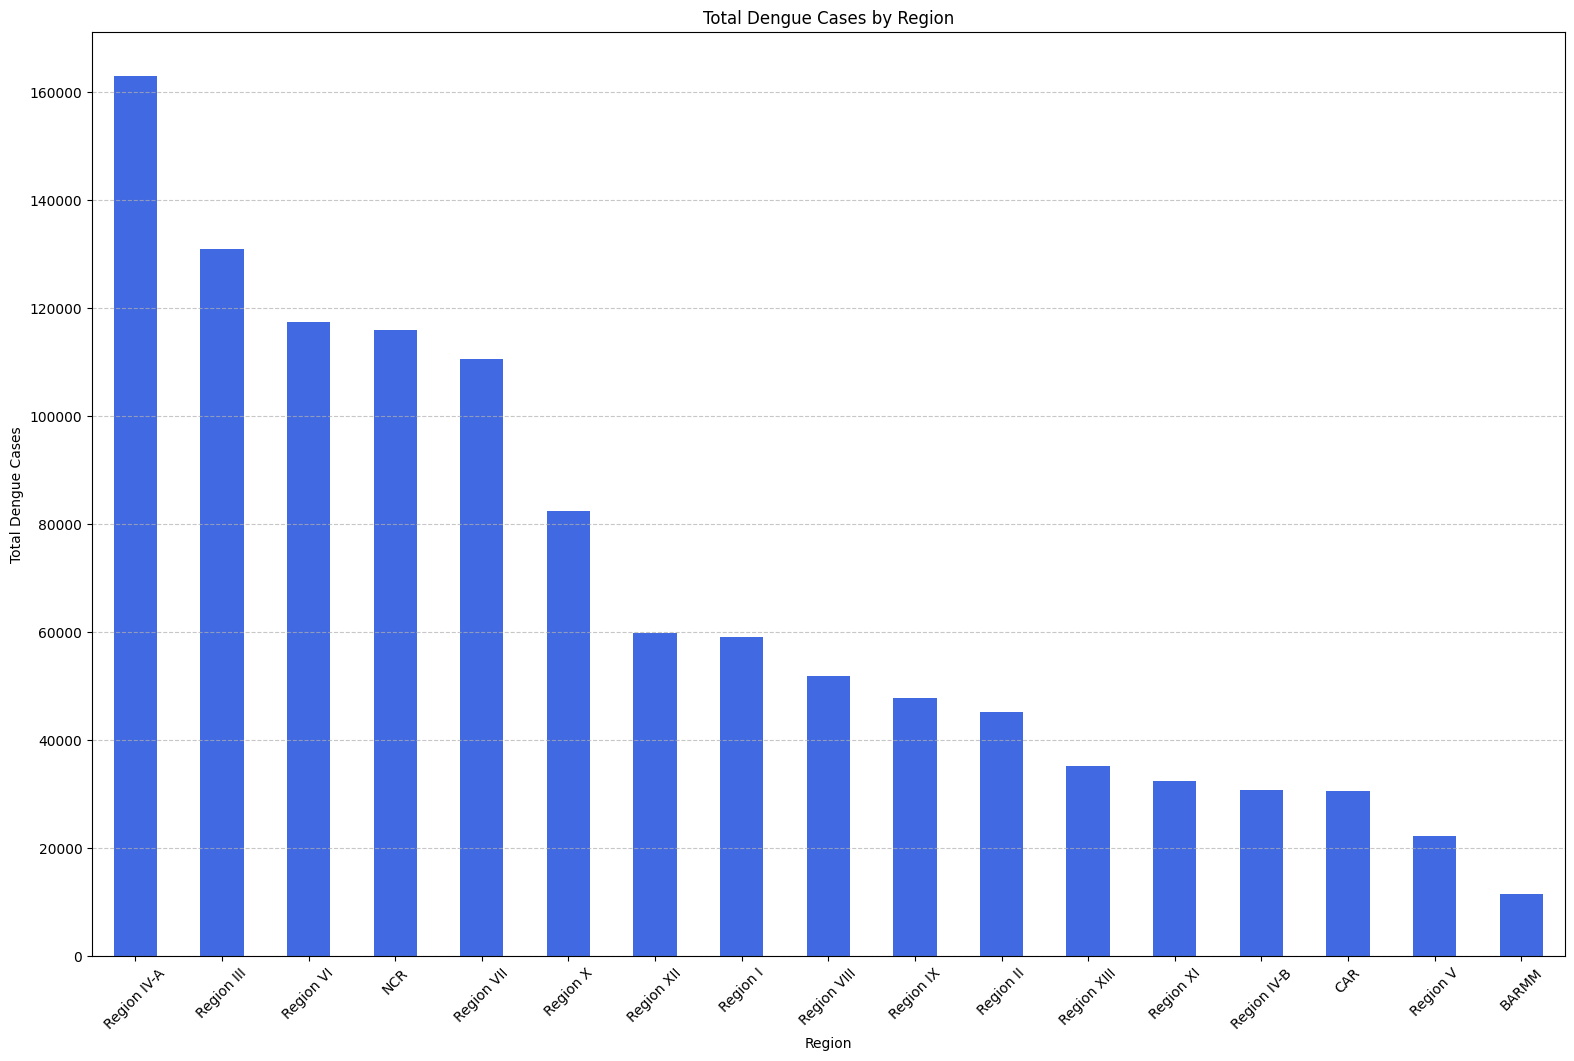

In [13]:
region_cases = dengue.groupby("Region")["Dengue_Cases"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
region_cases.plot(kind='bar', color='royalblue')
plt.gcf().set_size_inches(19,12)
plt.xlabel("Region")
plt.ylabel("Total Dengue Cases")
plt.title("Total Dengue Cases by Region")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# INSIGTH 3
So, according to this visualization, Region X has the highest dengue cases (Y cases), while Region Z has the lowest. This suggests that population density and poor sanitation contribute to outbreaks. Additionally, urban areas face higher risks due to stagnant water and construction. Peak cases during the rainy season highlight the need for fumigation and awareness campaigns.

# INSIGTH 4
So, according to this visualization, some regions consistently report higher dengue cases, indicating potential outbreak hotspots. This could be due to climate, urbanization, or ineffective mosquito control measures. Regions with lower cases may have better prevention strategies, which can be studied and applied to high-risk areas. 

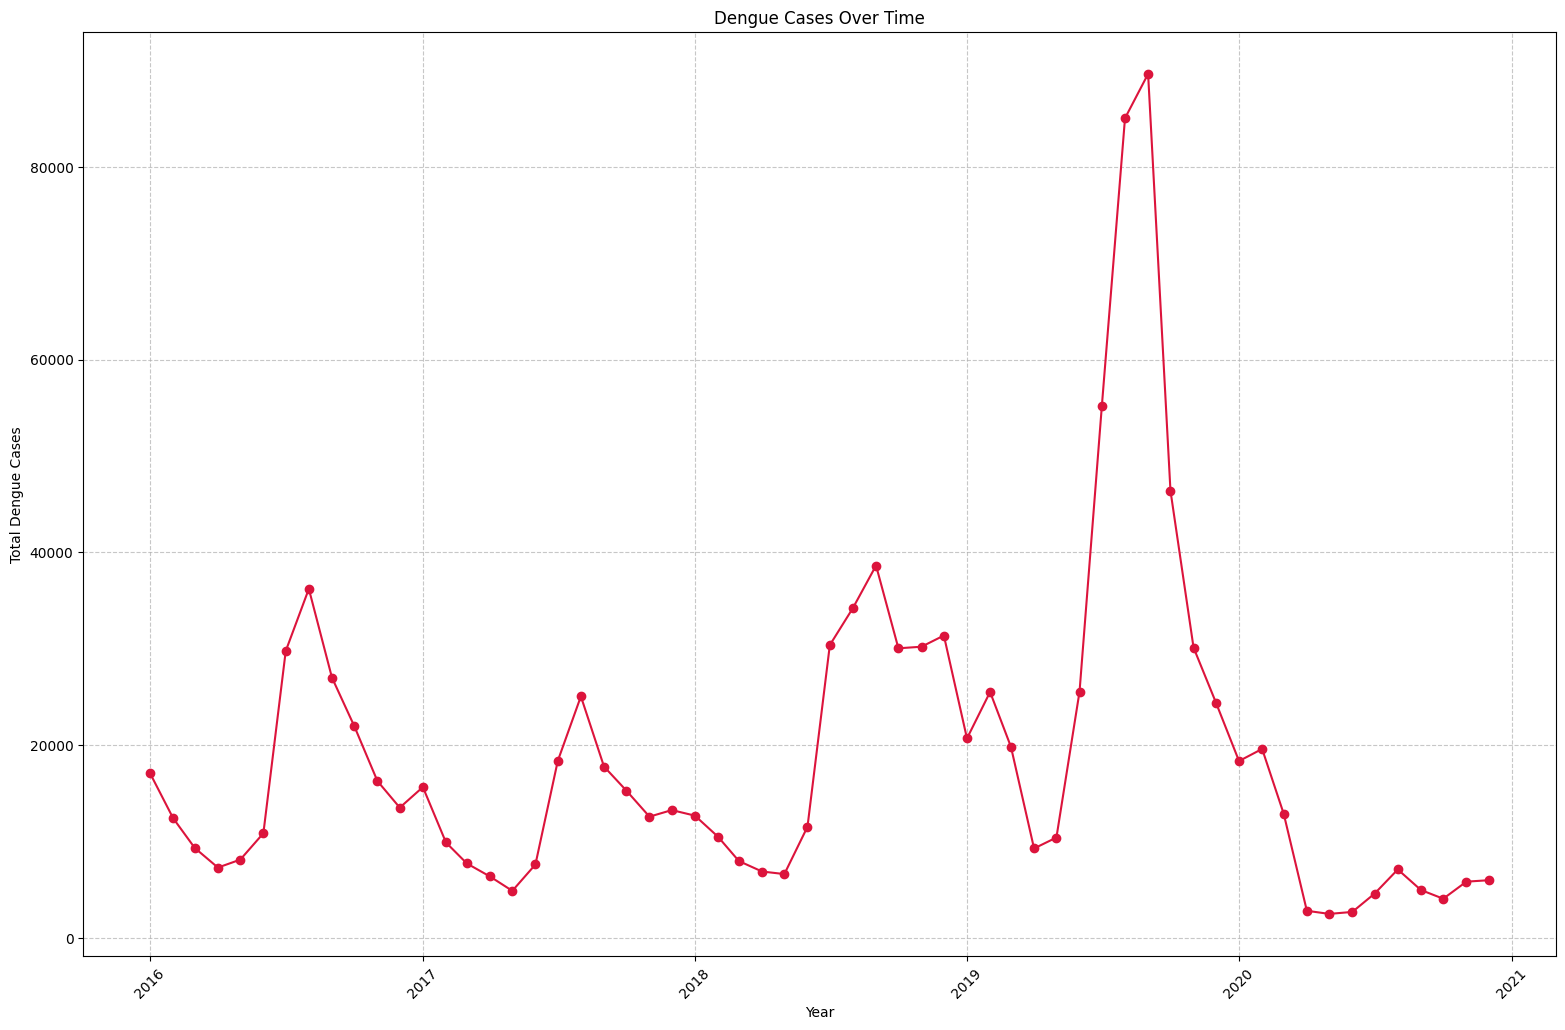

In [38]:
month_order = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

dengue['Month_Num'] = dengue['Month'].map(month_order)

dengue['Date'] = pd.to_datetime(dengue['Year'].astype(str) + '-' + dengue['Month_Num'].astype(str) + '-01')

time_series = dengue.groupby("Date")["Dengue_Cases"].sum()

plt.figure(figsize=(12, 6))
plt.plot(time_series.index, time_series.values, marker='o', linestyle='-', color='crimson')
plt.gcf().set_size_inches(19,12)
plt.xlabel("Year")
plt.ylabel("Total Dengue Cases")
plt.title("Dengue Cases Over Time")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# INSIGTH 5
So, according to this visualization, dengue cases show a recurring pattern, with peaks likely occurring during the rainy season, suggesting a strong seasonal influence on outbreaks. Additionally, certain years

# INSIGTH 6
So, according to this visualization, dengue cases follow a seasonal pattern, with spikes occurring in specific months, likely during the rainy season when mosquito breeding increases. Additionally, certain years show unusually high peaks, indicating possible major outbreaks that may require further investigation into climate conditions and public health responses

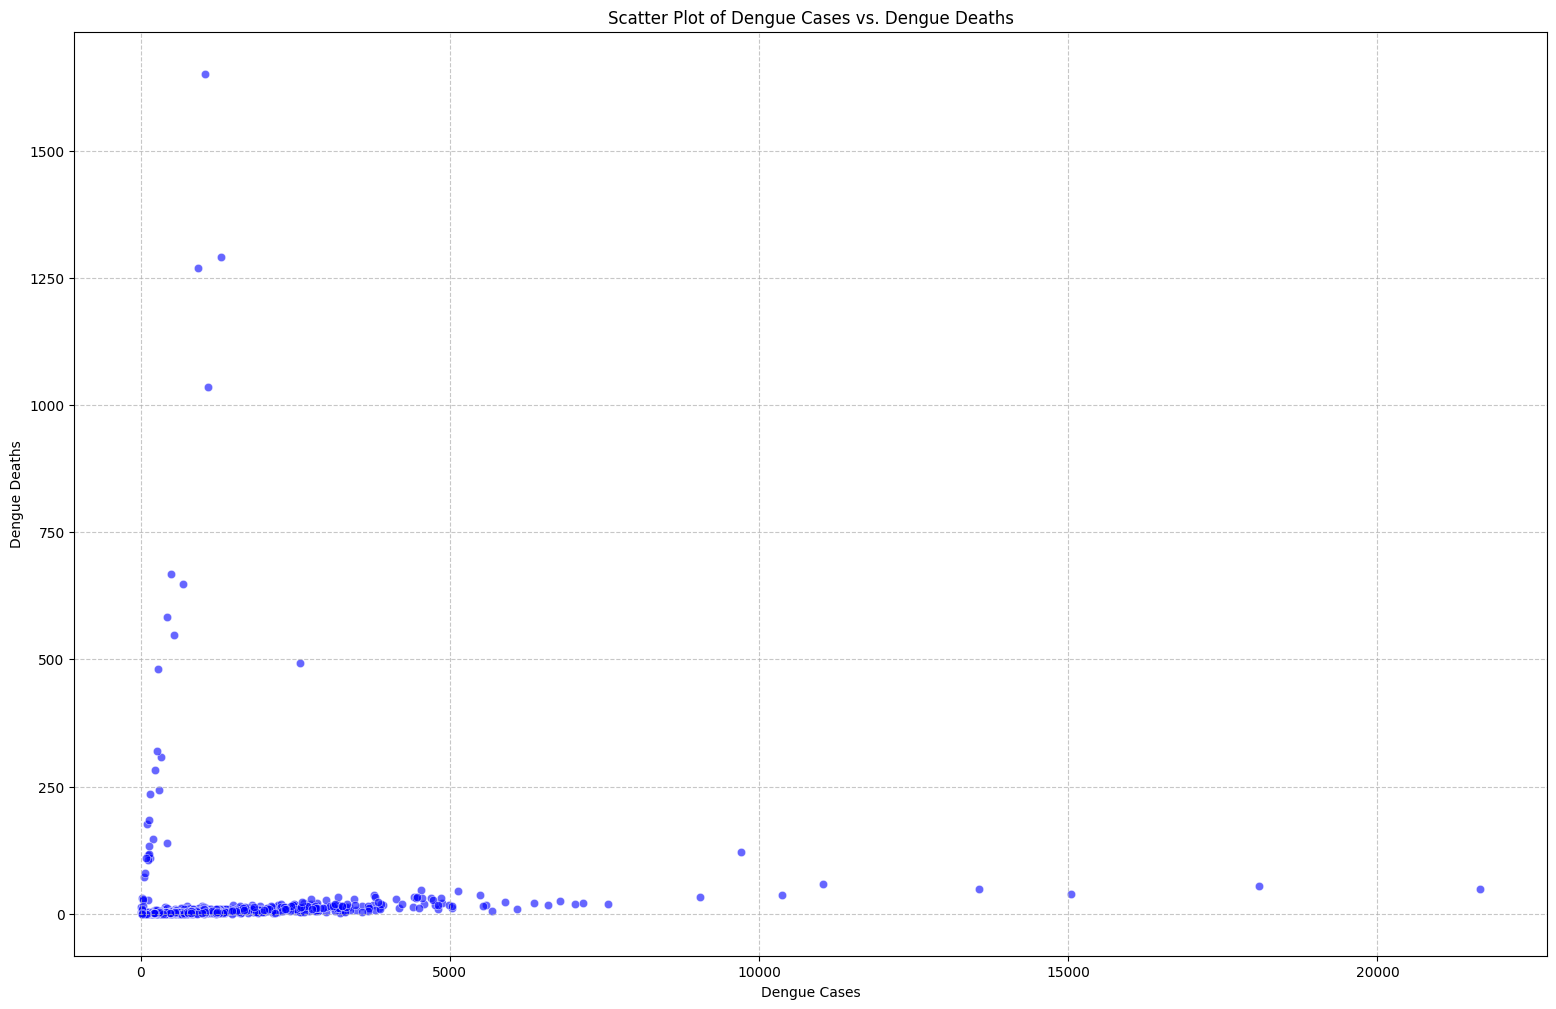

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=dengue["Dengue_Cases"], y=dengue["Dengue_Deaths"], color="blue", alpha=0.6)

plt.xlabel("Dengue Cases")
plt.gcf().set_size_inches(19,12)
plt.ylabel("Dengue Deaths")
plt.title("Scatter Plot of Dengue Cases vs. Dengue Deaths")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# INSIGTH 7
So, according to this visualization, there is a clear relationship between dengue cases and dengue deaths, where higher case numbers generally lead to more fatalities. However, some points show high cases with low deaths, suggesting effective medical treatment or early intervention. Additionally, outliers with high deaths but fewer cases may indicate severe outbreaks or underreported cases, which require further investigation.

# INSIGTH 8 
So, according to this visualization, most regions follow a pattern where higher dengue cases lead to more deaths, but some areas show disproportionately high fatalities, possibly due to limited healthcare access or late detection. Identifying these high-risk areas can help improve medical response and prevention efforts

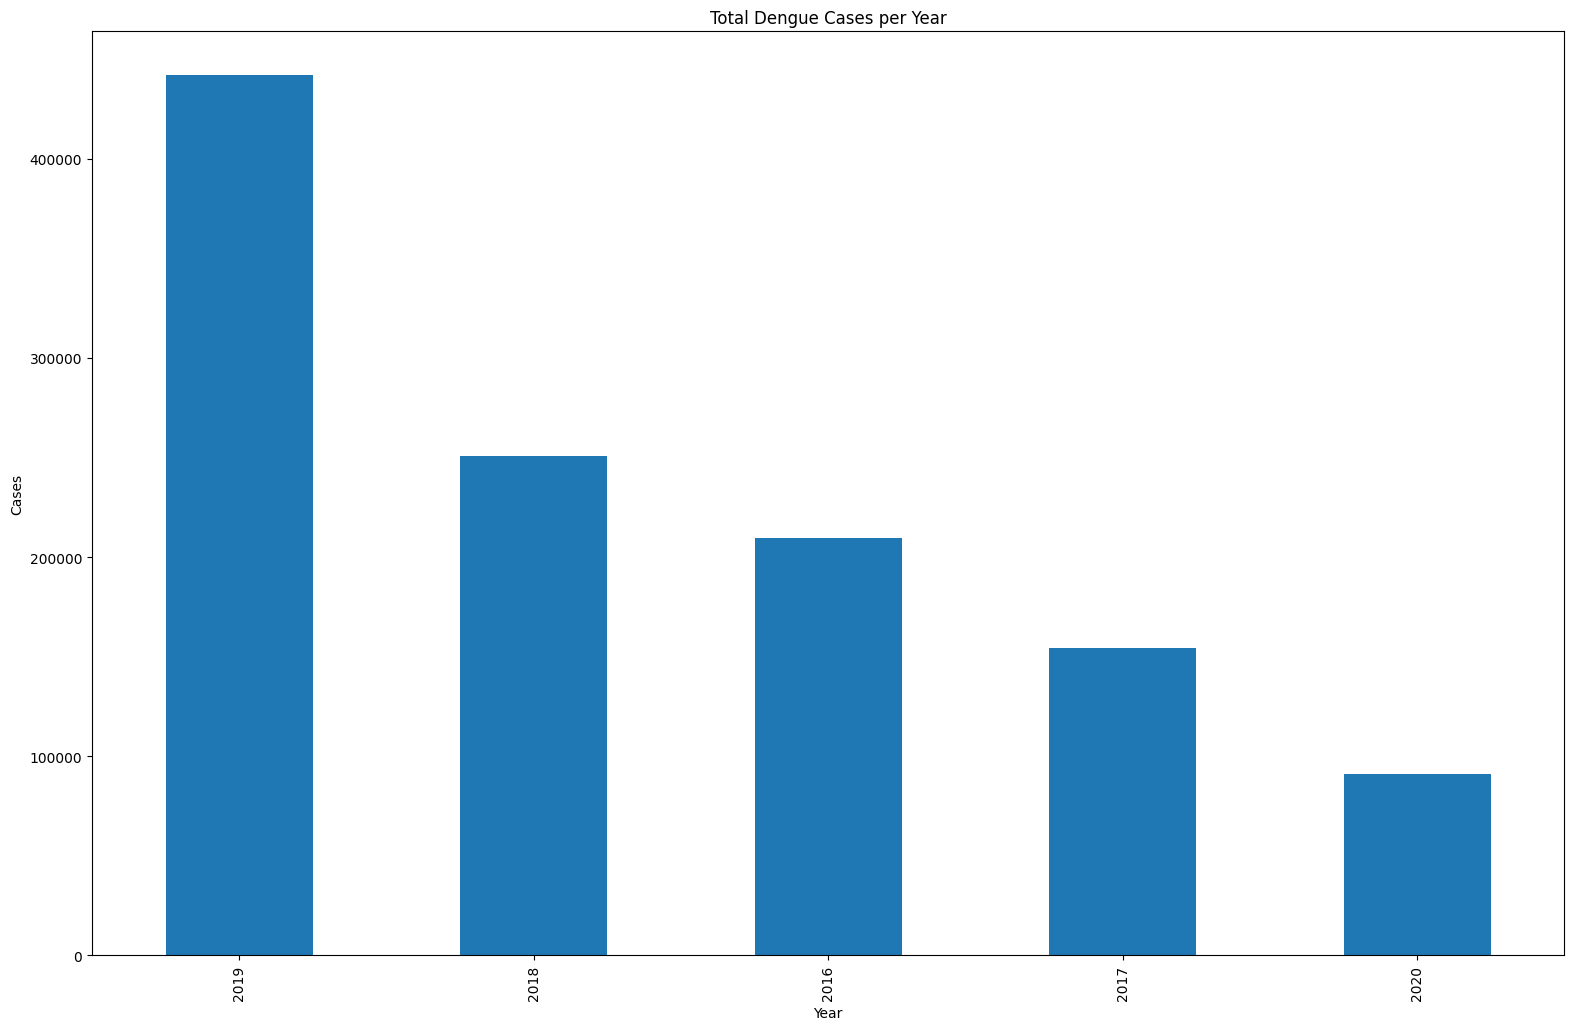

In [40]:
dengue.groupby('Year')['Dengue_Cases'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Dengue Cases per Year')
plt.gcf().set_size_inches(19,12)
plt.ylabel('Cases')
plt.show()

# INSIGTH 9 
 This show Which year recorded the highest number of dengue cases. And it is around 2018 to 2019 

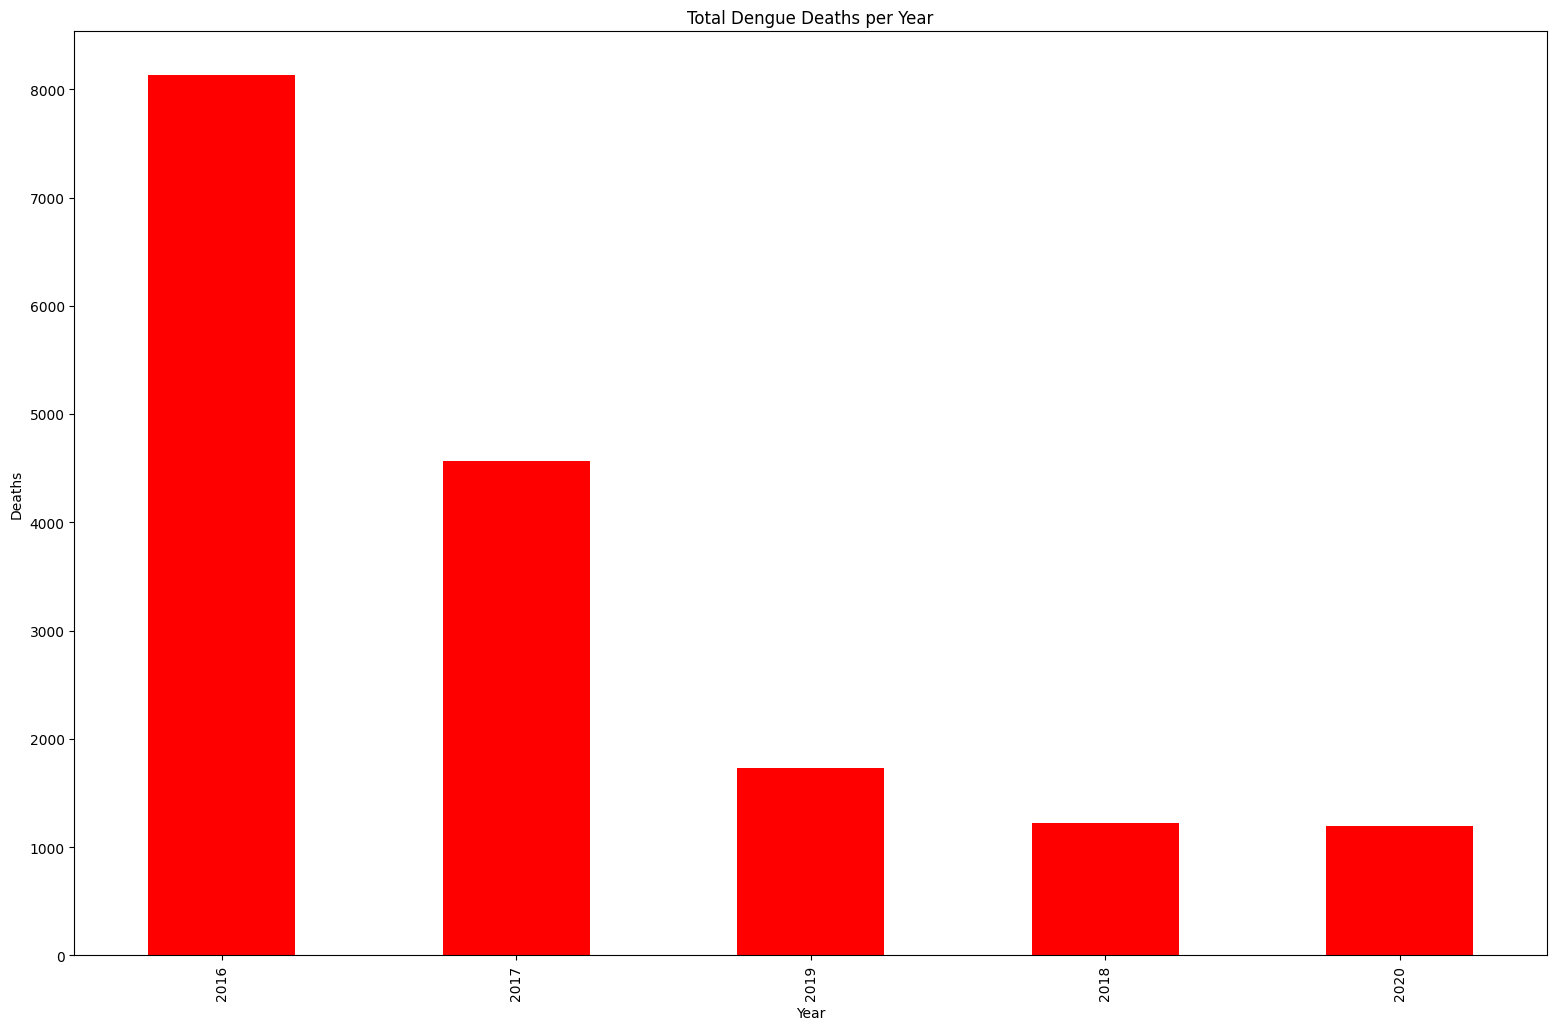

In [41]:
dengue.groupby('Year')['Dengue_Deaths'].sum().sort_values(ascending=False).plot(kind='bar', color='red')
plt.title('Total Dengue Deaths per Year')
plt.gcf().set_size_inches(19,12)
plt.ylabel('Deaths')
plt.show()


# INSIGTH 10

 The highiest year that has the highest number of dengue deaths occur to be around 2016 .
 


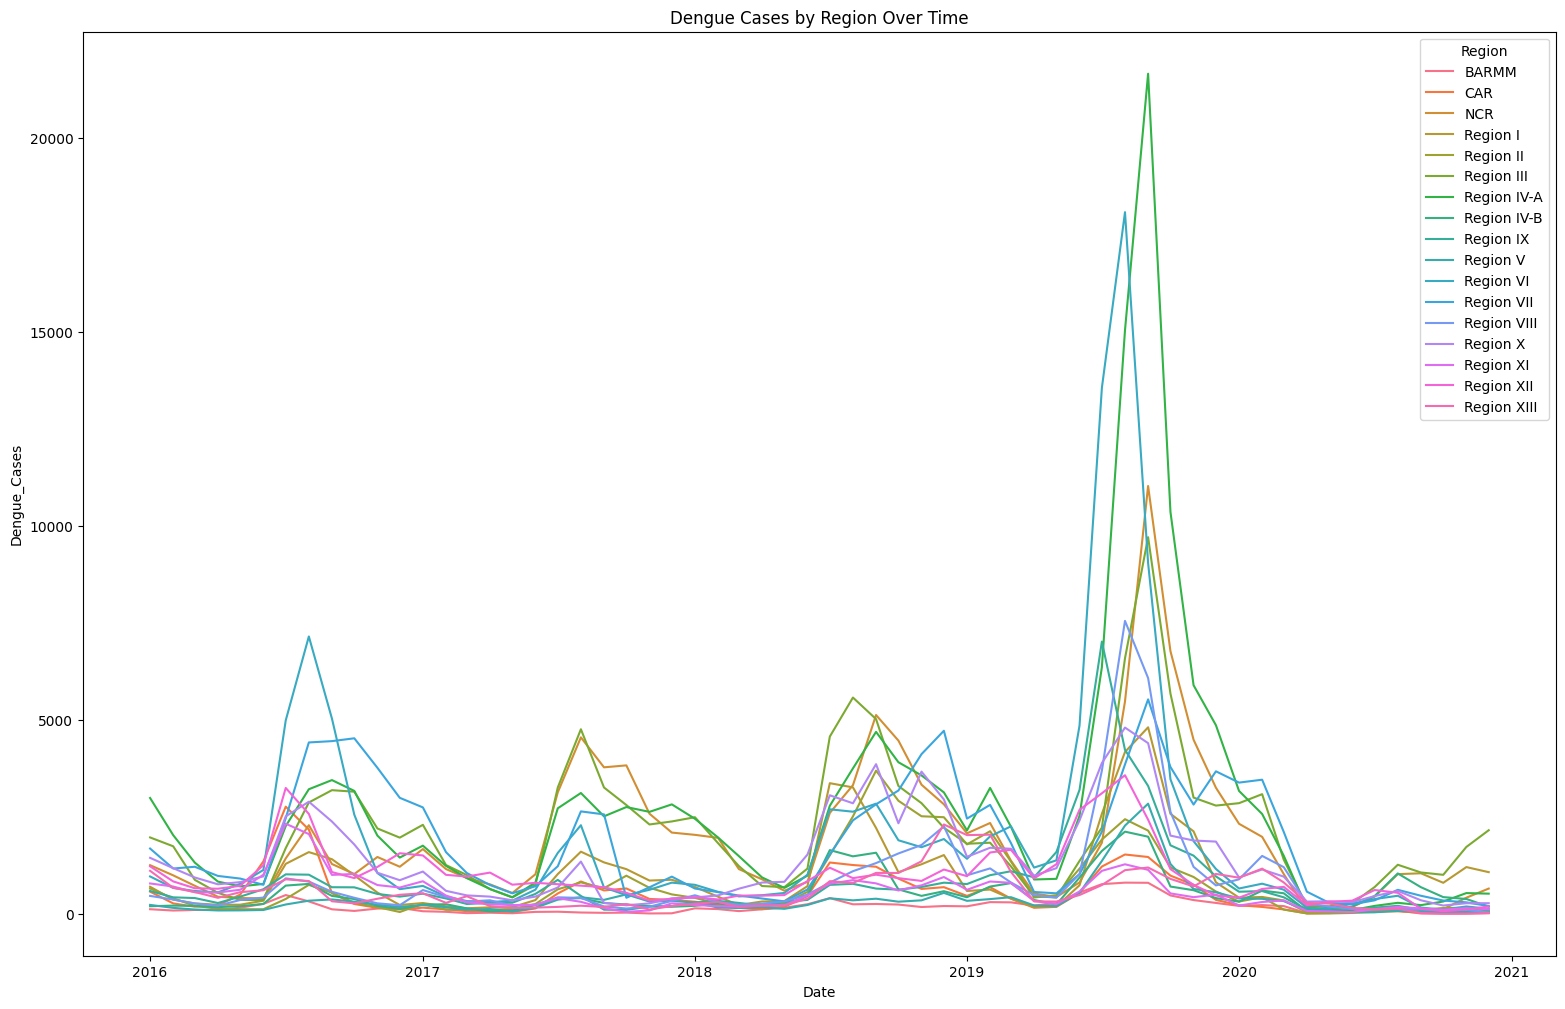

In [42]:
plt.figure(figsize=(12,6))
sns.lineplot(data=dengue, x='Date', y='Dengue_Cases', hue='Region')
plt.title('Dengue Cases by Region Over Time')
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 11
So this one show Which regions show increasing or decreasing trends over time?

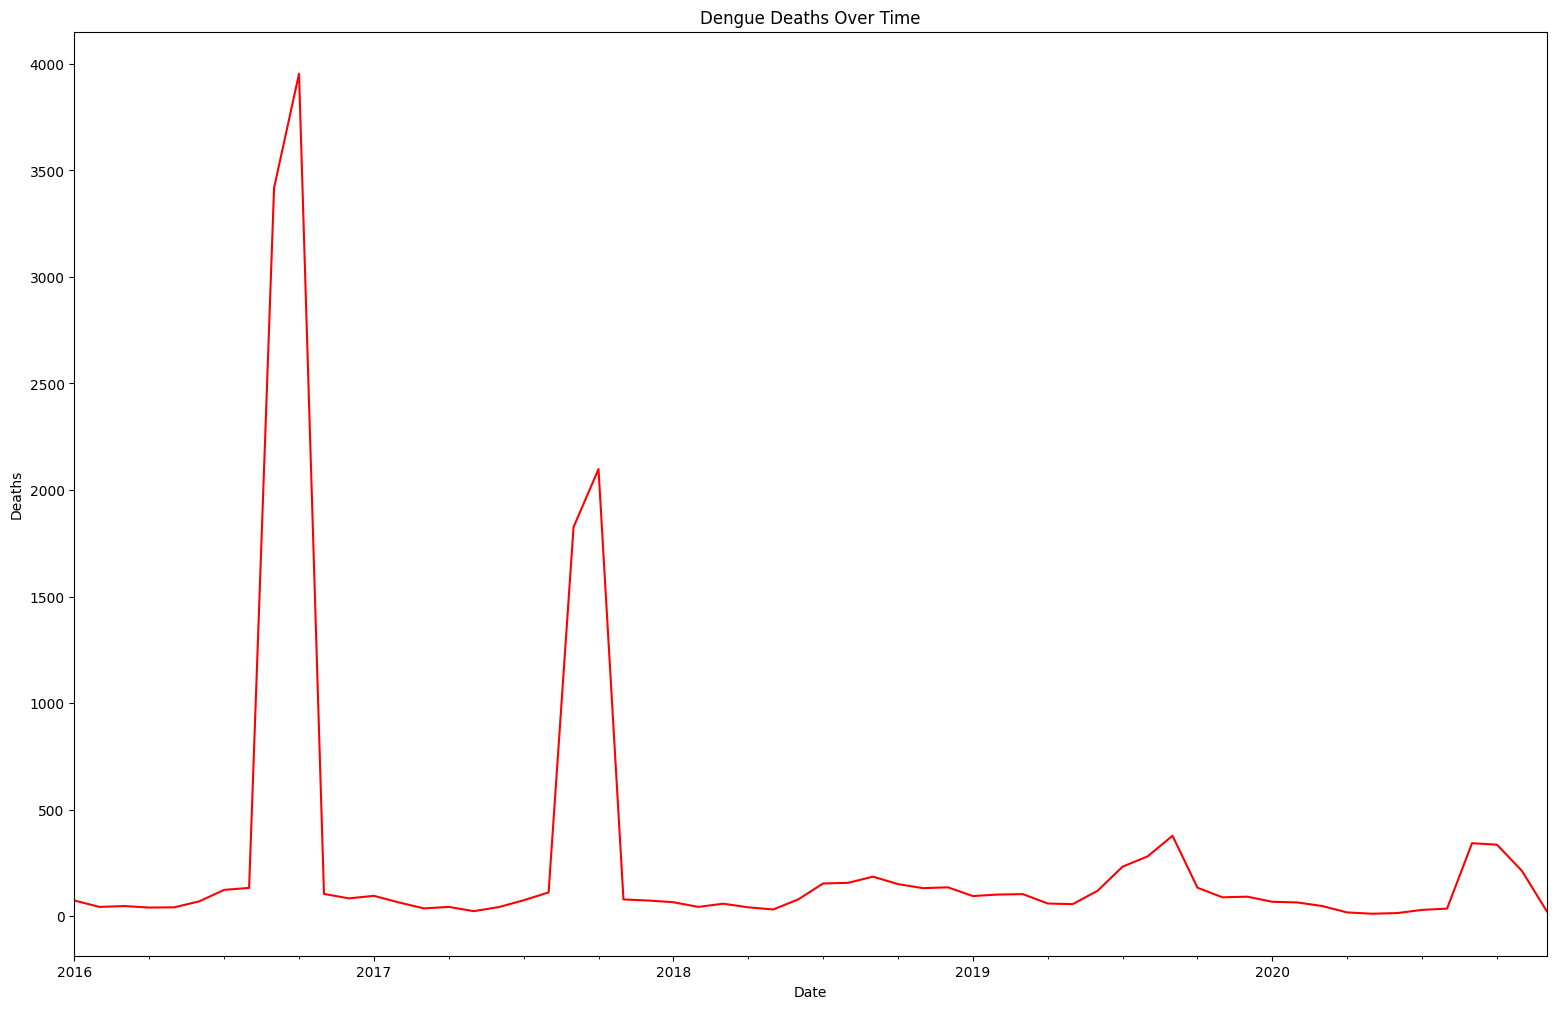

In [43]:
dengue.groupby('Date')['Dengue_Deaths'].sum().plot(color='red')
plt.title('Dengue Deaths Over Time')
plt.ylabel('Deaths')
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 12
This data show that deaths  because of dengue  case  increases on year around 2016 to 2017

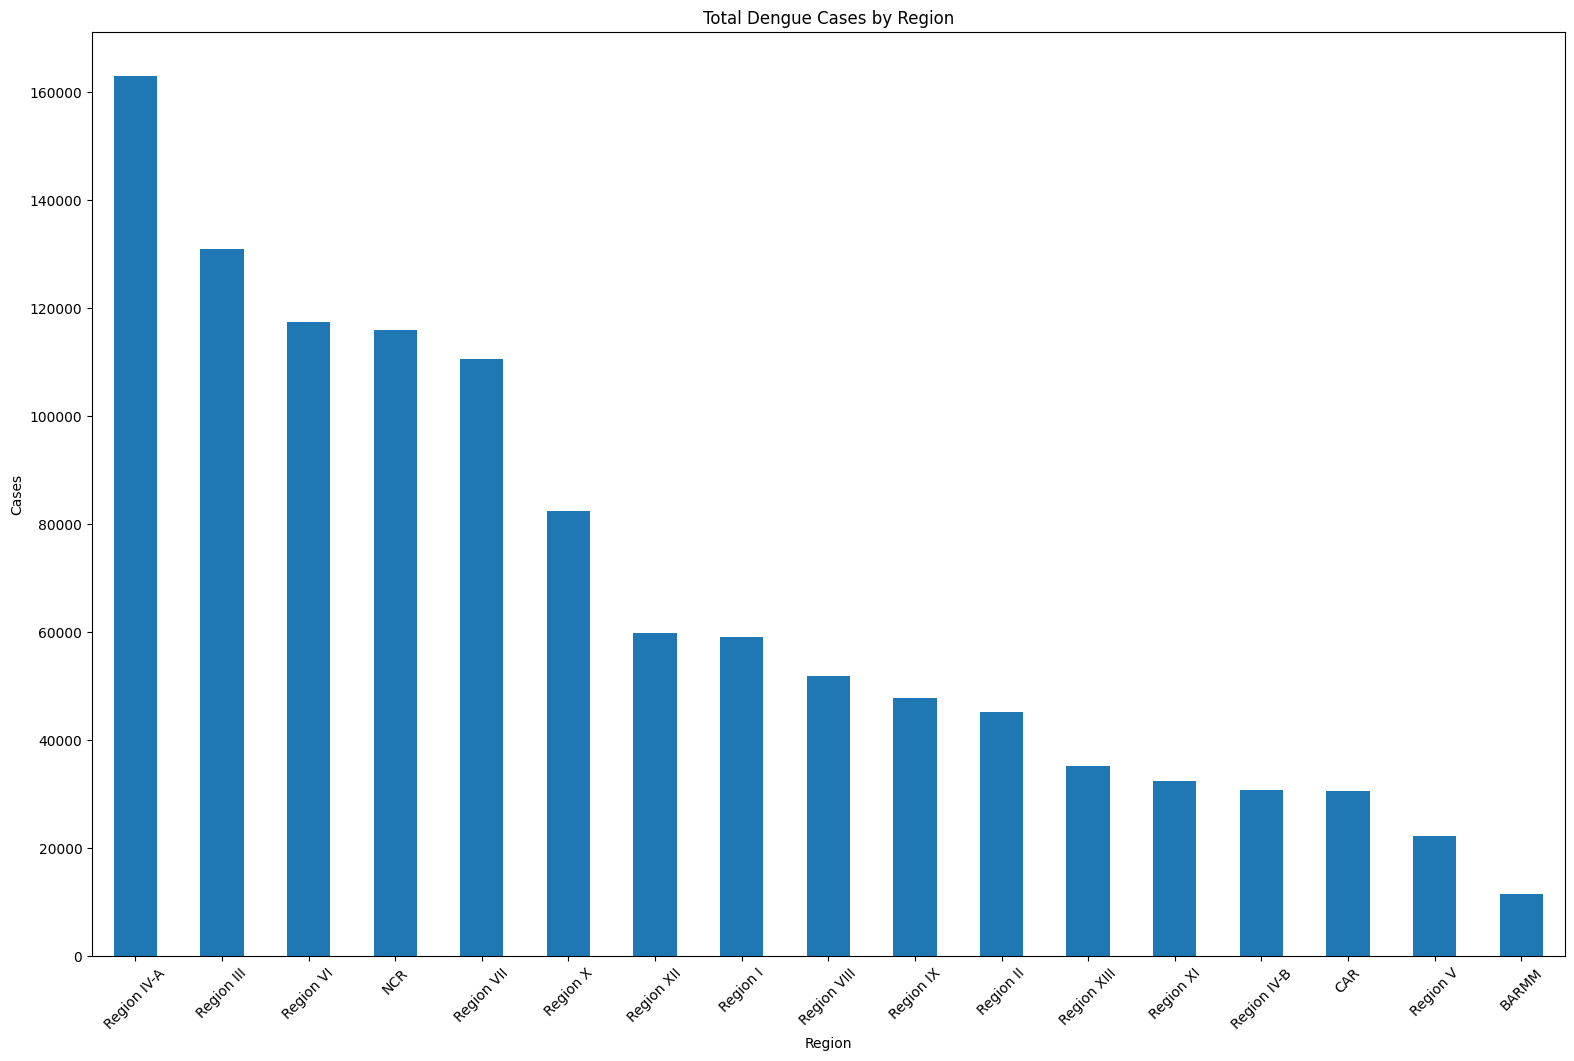

In [44]:
dengue.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Dengue Cases by Region')
plt.ylabel('Cases')
plt.xticks(rotation=45)
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 13
This data shows that the hisghest cases of dengue  aroused on region 4-A . This indicates that most of the cases of dengue data comes from this praticular region

# Is there a correlation between dengue cases and deaths?

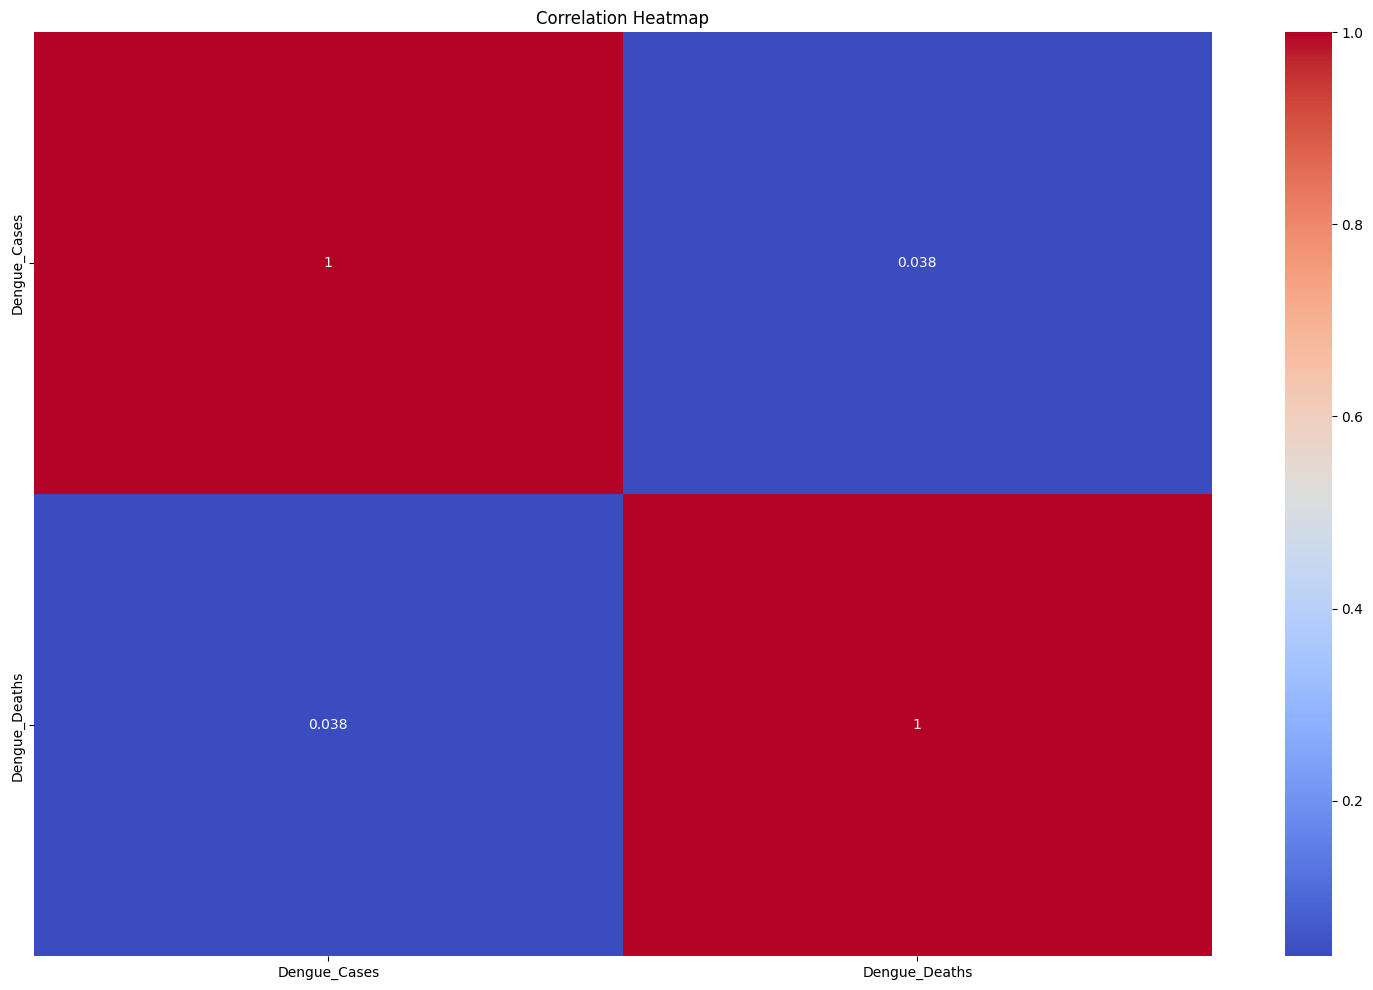

In [45]:
sns.heatmap(dengue[['Dengue_Cases', 'Dengue_Deaths']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 14
 There is a total correlation on dengue cases and the number of deaths 

# How have dengue cases changed over time?

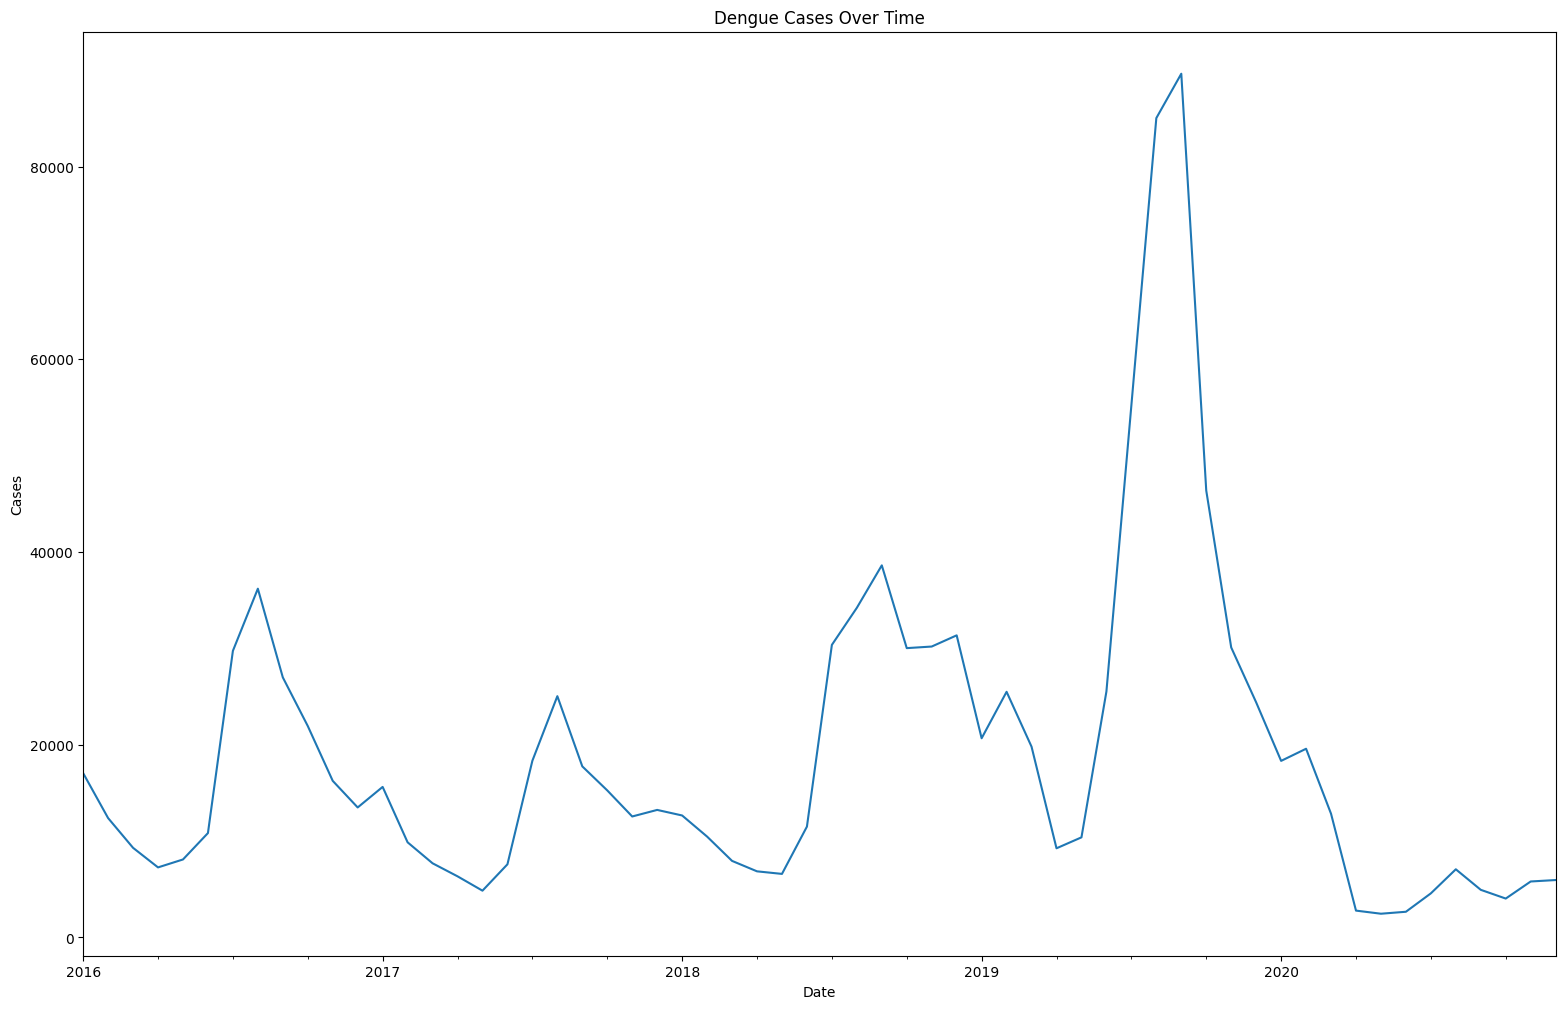

In [46]:
dengue.groupby('Date')['Dengue_Cases'].sum().plot()
plt.title('Dengue Cases Over Time')
plt.ylabel('Cases')
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 15
So according to this vishualization the cae of dengue changes over time  and note a highiest  case pn the year of 2019 to 2020.

#  Which regions show increasing or decreasing trends over time?


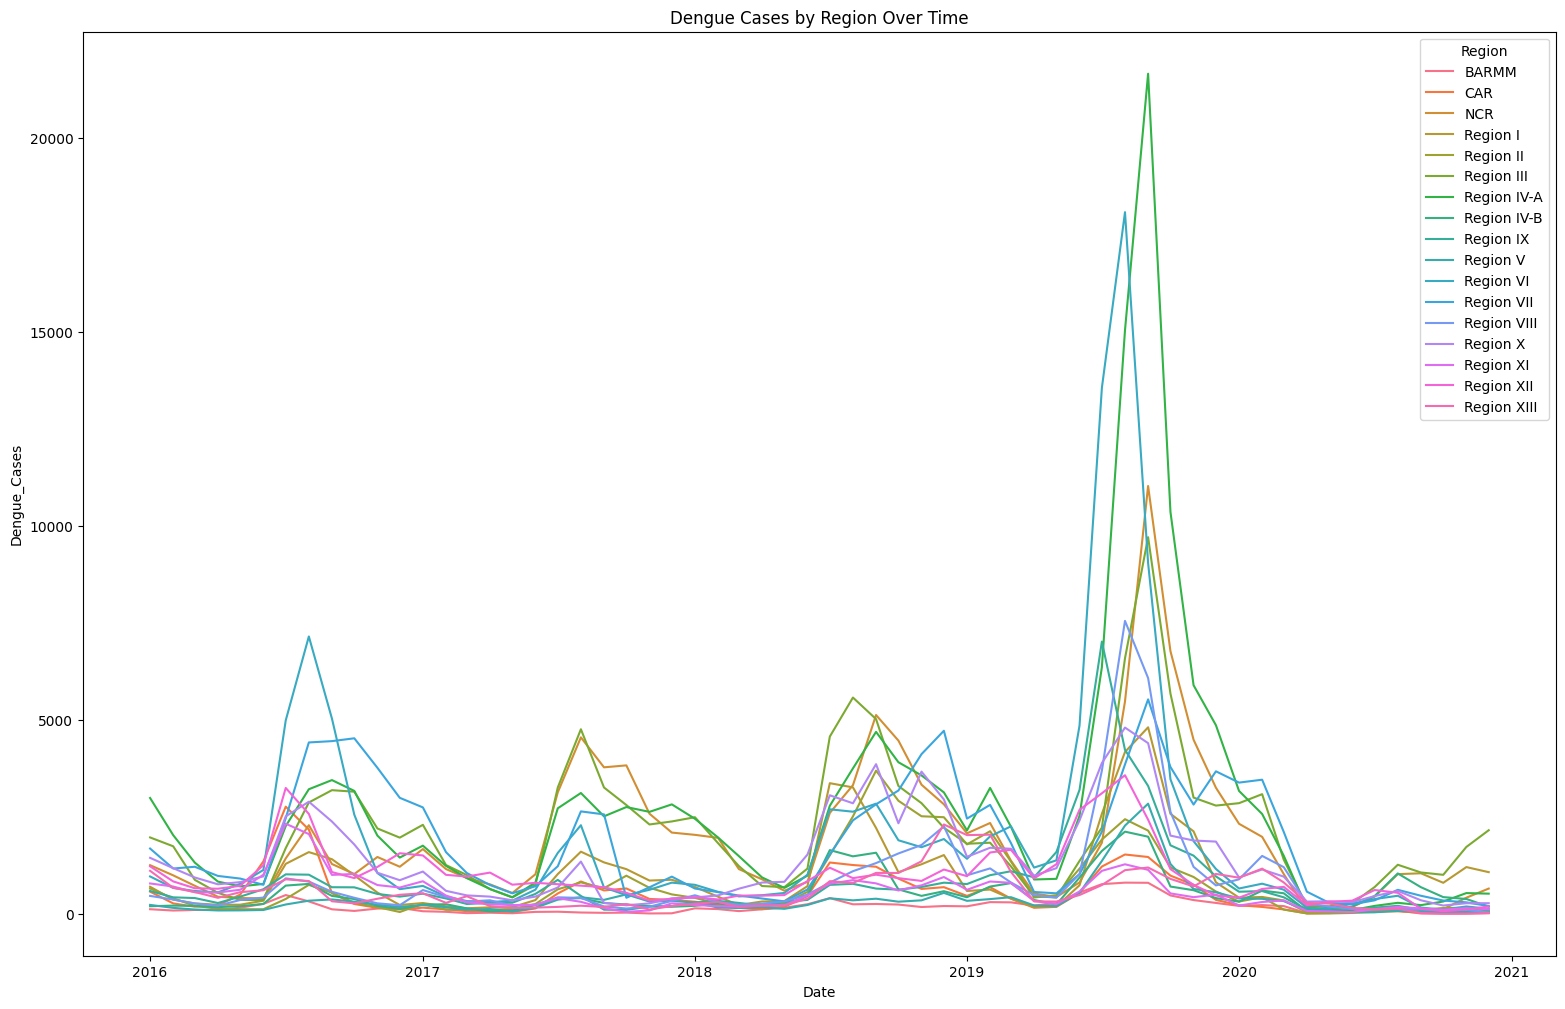

In [47]:
plt.figure(figsize=(12,6))
sns.lineplot(data=dengue, x='Date', y='Dengue_Cases', hue='Region')
plt.title('Dengue Cases by Region Over Time')
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 16
So based on this , the regions IV-A and VII increases over the time period 

#  In which year did dengue deaths peak?

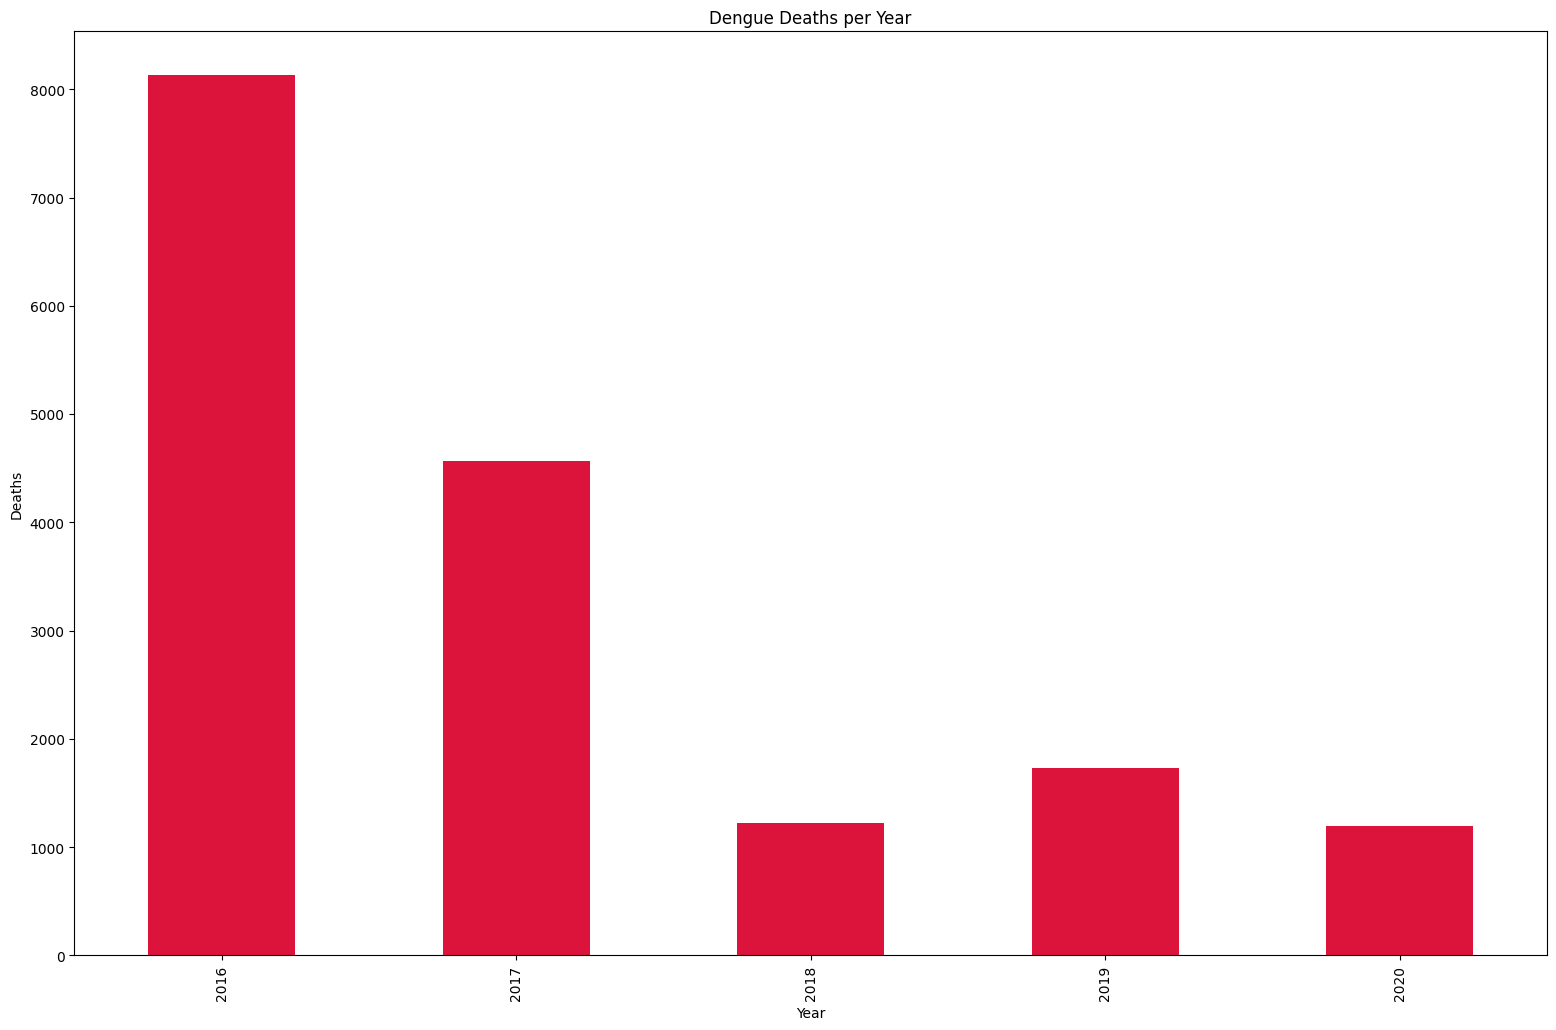

In [48]:
dengue.groupby('Year')['Dengue_Deaths'].sum().plot(kind='bar', color='crimson')
plt.title('Dengue Deaths per Year')
plt.gcf().set_size_inches(19,12)
plt.ylabel('Deaths')
plt.show()

# INSIGTH 17
Year 2016  the dengue case deaths peaks. Meaning this year is the highest number of deaths due to dengue .

#  Which regions recorded the least dengue deaths?

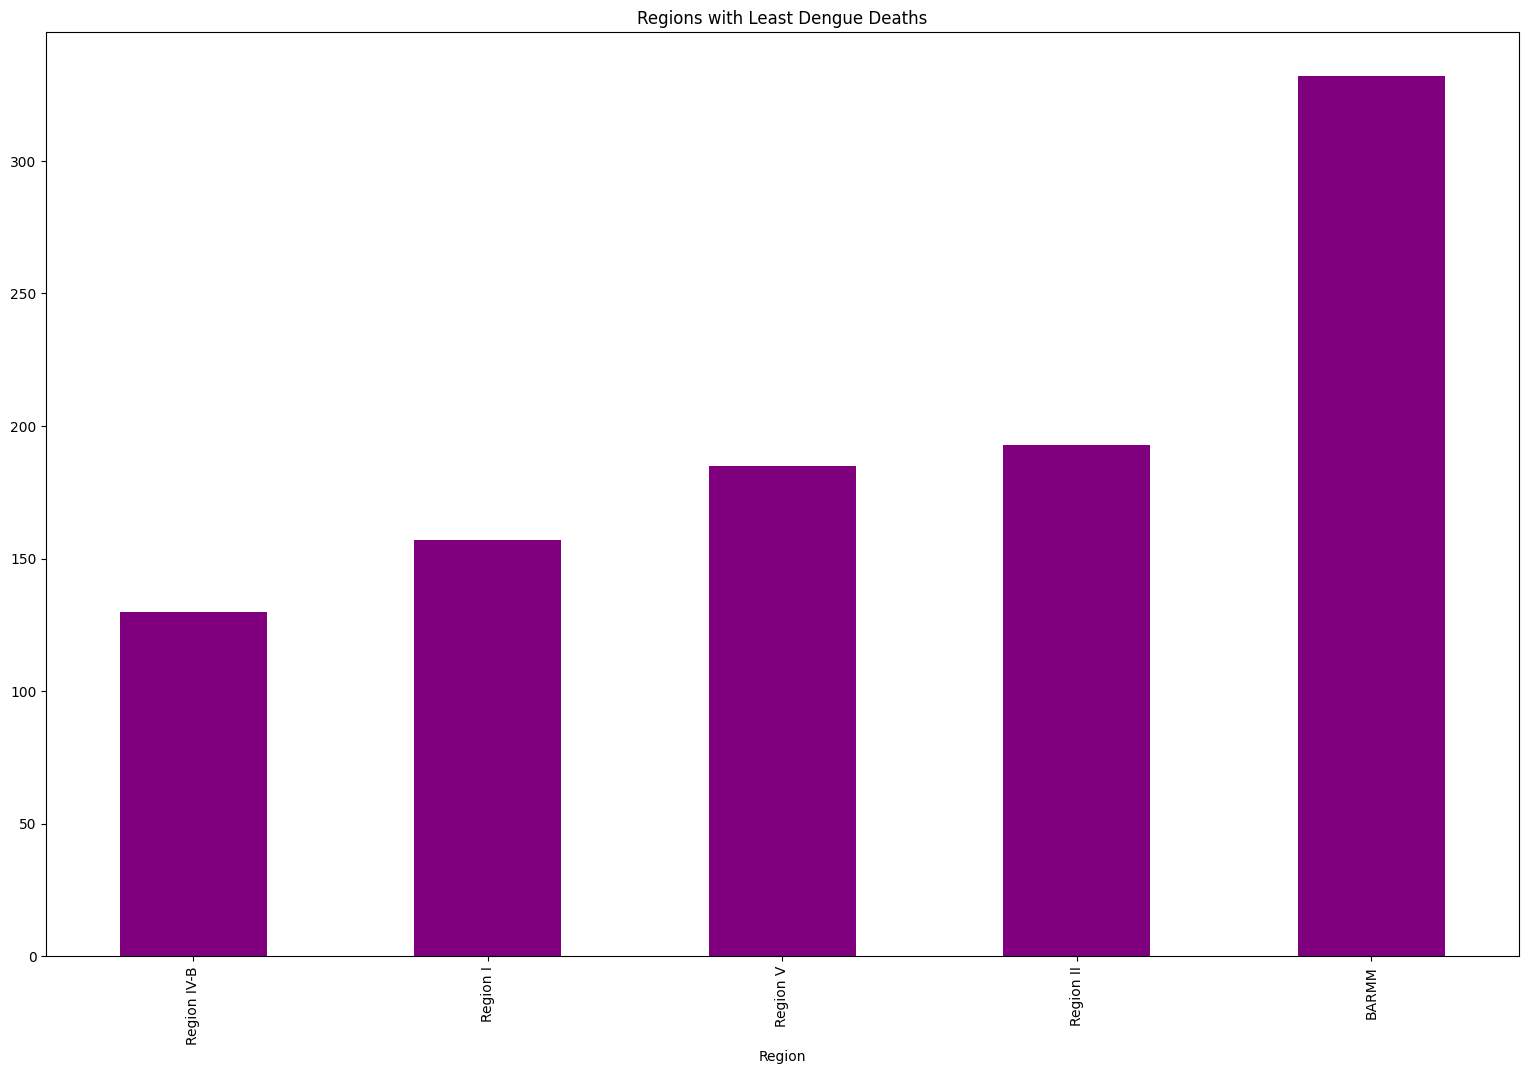

In [49]:
dengue.groupby('Region')['Dengue_Deaths'].sum().sort_values().head(5).plot(kind='bar', color='purple')
plt.title('Regions with Least Dengue Deaths')
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 18
So Region IV-B sets the lowest case rate of the dengue  cases from the certain time said.


# What are the average cases and deaths per region?


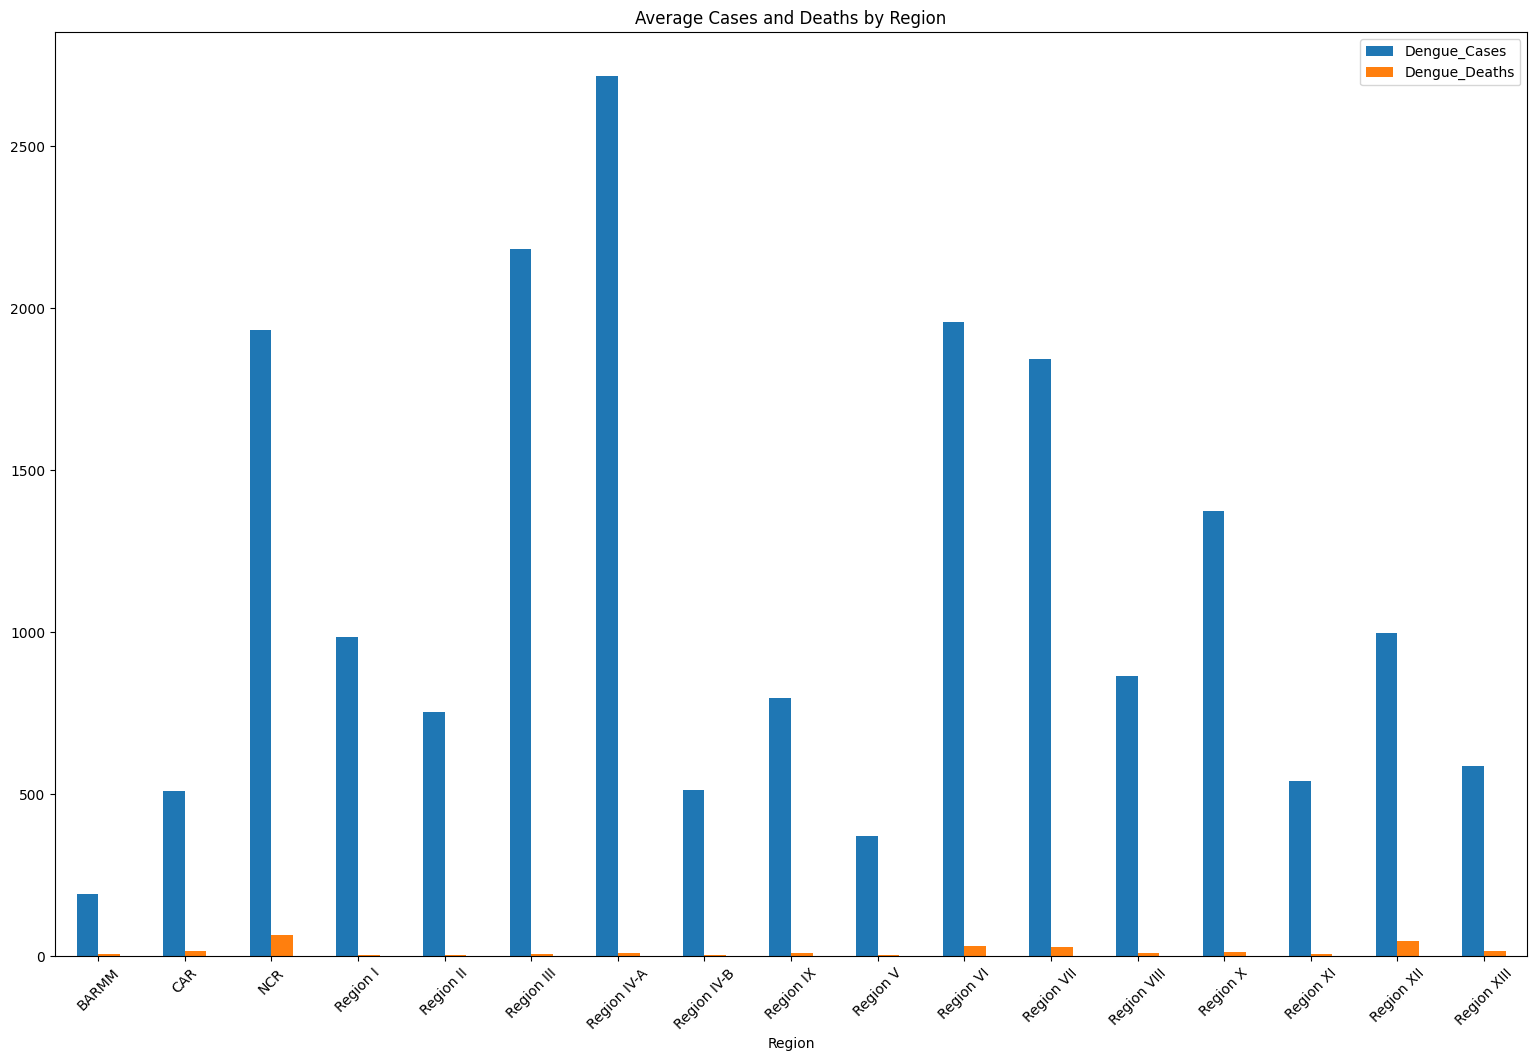

In [50]:
dengue.groupby('Region')[['Dengue_Cases', 'Dengue_Deaths']].mean().plot(kind='bar')
plt.title('Average Cases and Deaths by Region')
plt.xticks(rotation=45)
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 19
So this Shows that the average deaths of dengue cases peaks to almost above 2500 percent.

#  How do dengue cases vary by region and month?

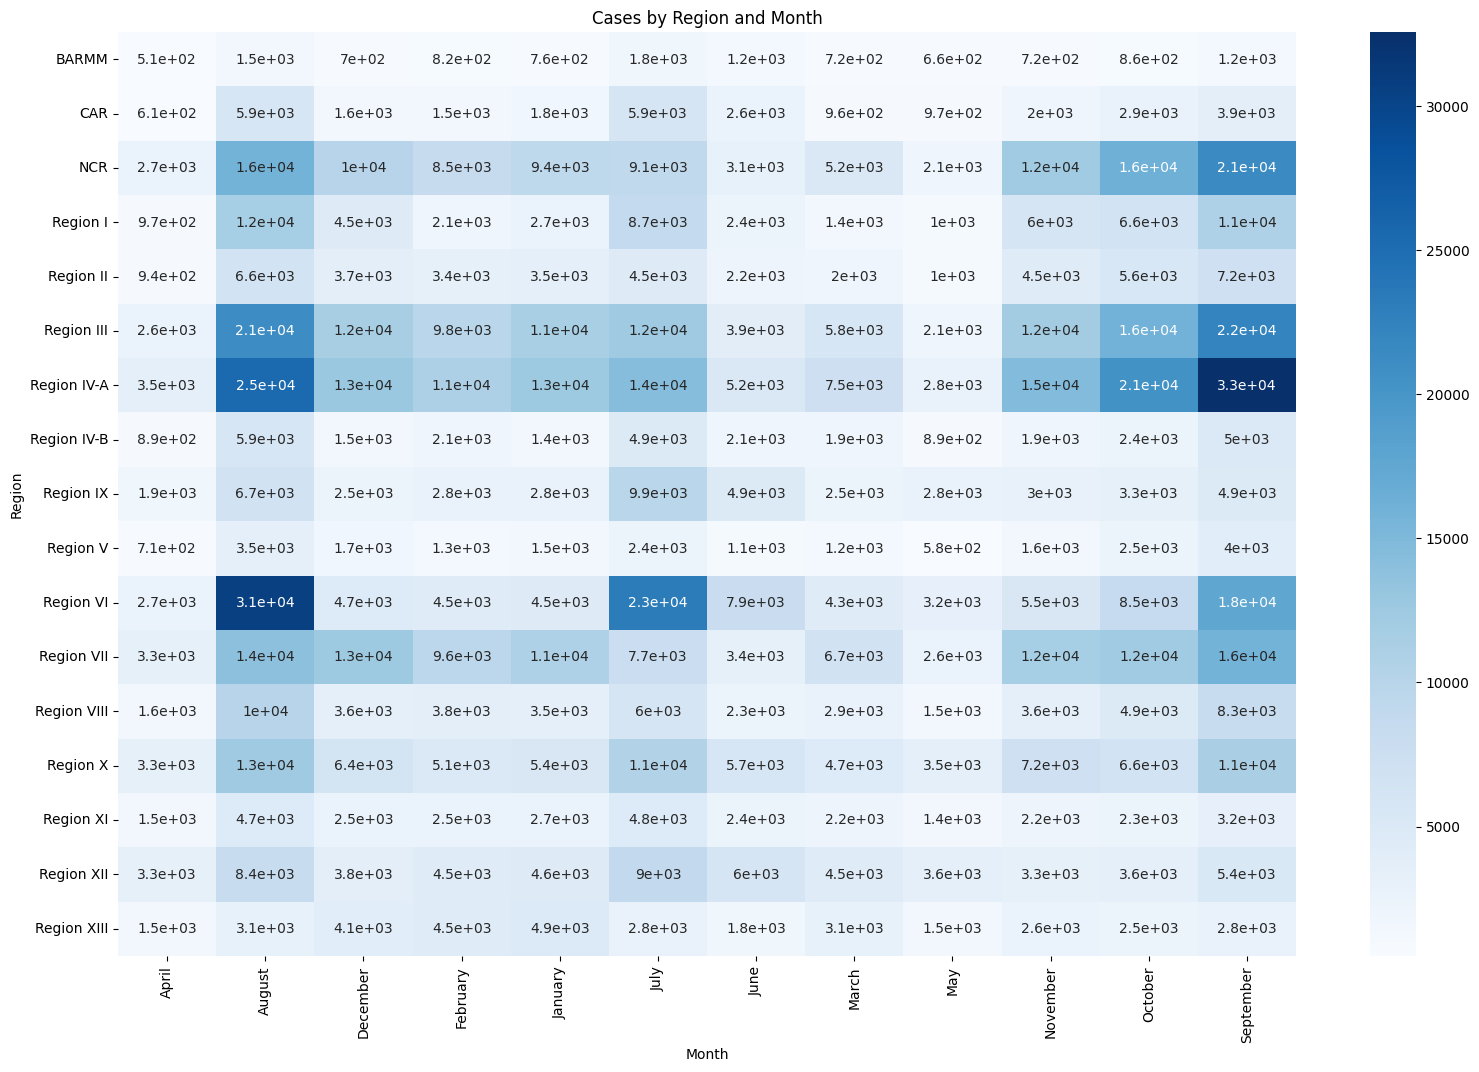

In [51]:
sns.heatmap(dengue.pivot_table(values='Dengue_Cases', index='Region', columns='Month', aggfunc='sum'), cmap='Blues', annot=True)
plt.title('Cases by Region and Month')
plt.gcf().set_size_inches(19,12)
plt.show()

# INSIGTH 20
So this shows how dengue case vary on every month per each regions. This shows how and when the cases of every regions increases or decreases